In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, ttest_ind, f_oneway

plt.rcParams["figure.figsize"] = (10,6)

In [2]:
df = pd.read_csv("../data/raw/superstore.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [3]:
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData Types")
print(df.dtypes)

DATASET INFORMATION
Rows: 9994
Columns: 22

Data Types
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Shipping Days             int64
dtype: object


In [4]:
df[
    [
        "Sales",
        "Profit",
        "Discount",
        "Quantity",
        "Shipping Days"
    ]
].describe()

,Sales,Profit,Discount,Quantity,Shipping Days
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574,3.958175
std,623.245101,234.260108,0.206452,2.225110,1.747567
min,0.444000,-6599.978000,0.000000,1.000000,0.000000
25%,17.280000,1.728750,0.000000,2.000000,3.000000
50%,54.490000,8.666500,0.200000,3.000000,4.000000
75%,209.940000,29.364000,0.200000,5.000000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000,7.000000


In [5]:
corr, p_value = pearsonr(df["Sales"], df["Profit"])

print("=" * 50)
print("PEARSON CORRELATION TEST")
print("=" * 50)

print(f"Correlation Coefficient : {corr:.4f}")
print(f"P-value                 : {p_value:.10f}")

PEARSON CORRELATION TEST
Correlation Coefficient : 0.4791
P-value                 : 0.0000000000


# Pearson Correlation Test

This test measures the linear relationship between **Sales** and **Profit**.

### Hypotheses

- **H₀ (Null Hypothesis):** There is no significant linear relationship between Sales and Profit.
- **H₁ (Alternative Hypothesis):** There is a significant linear relationship between Sales and Profit.

If the p-value is less than **0.05**, we reject the null hypothesis.

In [6]:
tech_profit = df[df["Category"] == "Technology"]["Profit"]

furniture_profit = df[df["Category"] == "Furniture"]["Profit"]

t_stat, p_value = ttest_ind(tech_profit, furniture_profit)

print("=" * 50)
print("INDEPENDENT T-TEST")
print("=" * 50)

print(f"T Statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.10f}")

INDEPENDENT T-TEST
T Statistic : 7.1232
P-value     : 0.0000000000


# Independent T-Test

This test compares the **average profit** between the Technology and Furniture categories.

### Hypotheses

- **H₀:** The average profit of Technology and Furniture is equal.
- **H₁:** The average profit is different.

In [7]:
consumer = df[df["Segment"] == "Consumer"]["Sales"]

corporate = df[df["Segment"] == "Corporate"]["Sales"]

home_office = df[df["Segment"] == "Home Office"]["Sales"]

f_stat, p_value = f_oneway(
    consumer,
    corporate,
    home_office
)

print("=" * 50)
print("ONE-WAY ANOVA")
print("=" * 50)

print(f"F Statistic : {f_stat:.4f}")
print(f"P-value     : {p_value:.10f}")

ONE-WAY ANOVA
F Statistic : 0.5952
P-value     : 0.5514734706


# One-Way ANOVA

This test determines whether **average sales differ across customer segments**.

### Hypotheses

- **H₀:** All customer segments have the same average sales.
- **H₁:** At least one customer segment has a different average sales value.

# Statistical Test Results

## 1. Pearson Correlation Test

- Correlation Coefficient: **0.4791**
- P-value: **< 0.0001**

### Interpretation

The Pearson correlation coefficient indicates a **moderate positive relationship** between Sales and Profit.

Since the p-value is significantly less than **0.05**, the relationship is **statistically significant**.

**Conclusion:** As sales increase, profits generally increase as well, although the relationship is not perfectly linear.

---

## 2. Independent T-Test

- T Statistic: **7.1232**
- P-value: **< 0.0001**

### Interpretation

The p-value is much smaller than **0.05**, so we reject the null hypothesis.

**Conclusion:** The average profit of the Technology category is significantly different from the Furniture category.

This supports the EDA findings that Technology products generate much higher profits.

---

## 3. One-Way ANOVA

- F Statistic: **0.5952**
- P-value: **0.5515**

### Interpretation

The p-value is greater than **0.05**.

Therefore, we fail to reject the null hypothesis.

**Conclusion:** There is no statistically significant difference in average sales among the Consumer, Corporate, and Home Office customer segments.

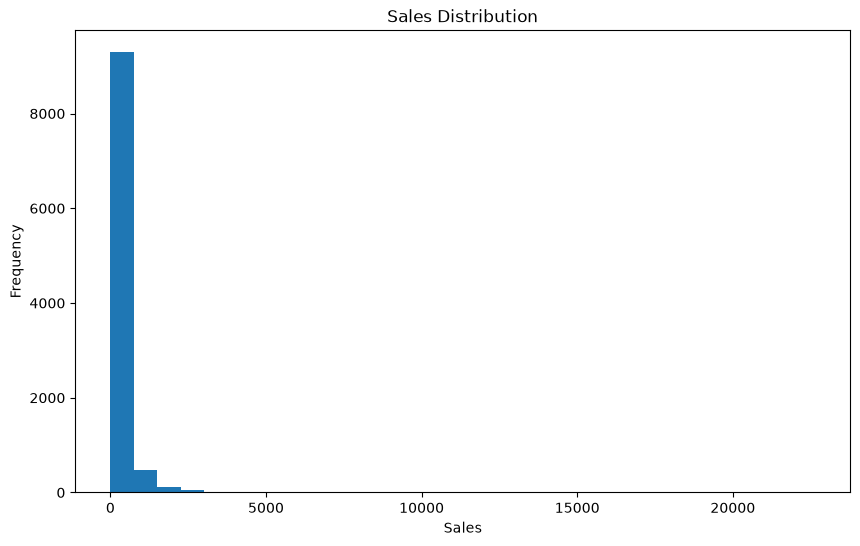

In [8]:
plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

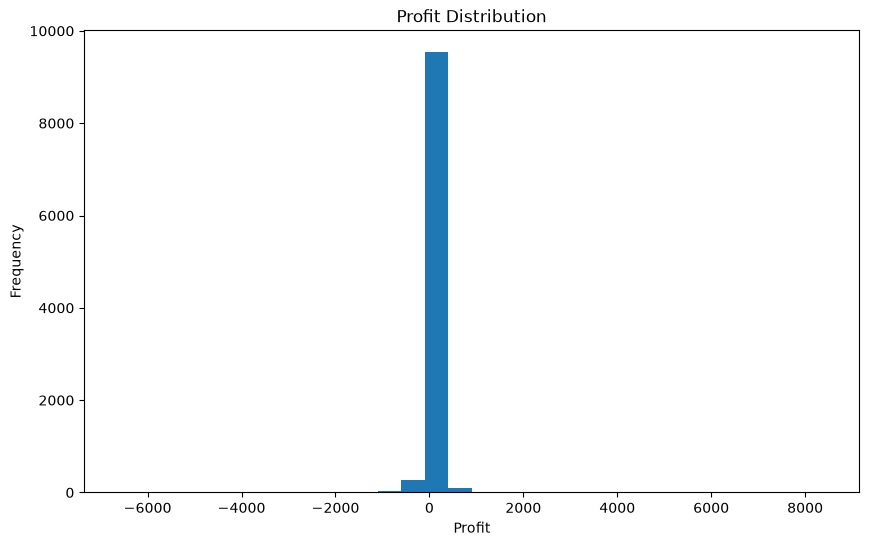

In [9]:
plt.hist(df["Profit"], bins=30)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

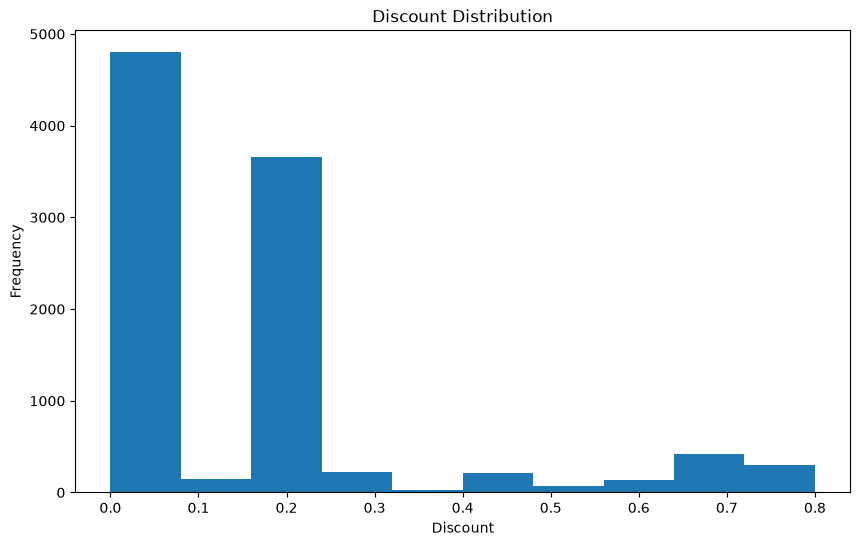

In [10]:
plt.hist(df["Discount"], bins=10)

plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")

plt.show()

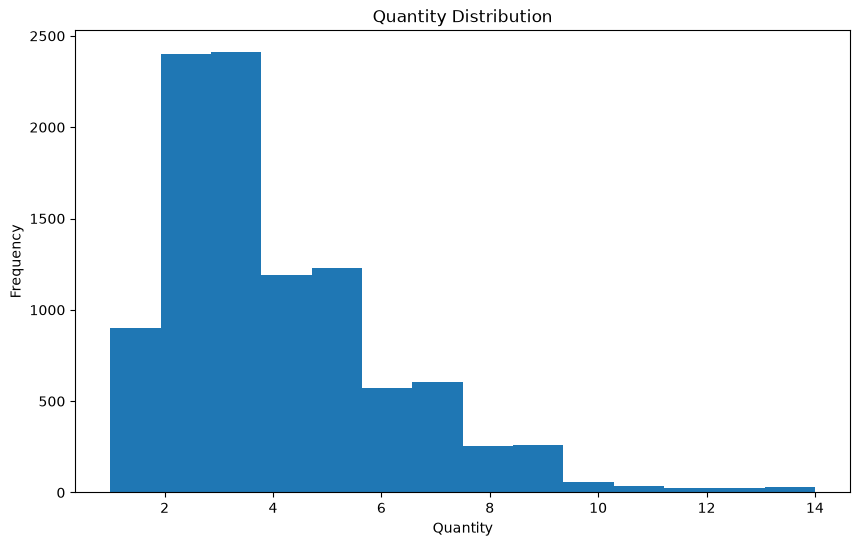

In [11]:
plt.hist(df["Quantity"], bins=14)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

# Statistical Analysis Summary

## Techniques Used

- Descriptive Statistics
- Pearson Correlation Analysis
- Independent T-Test
- One-Way ANOVA
- Distribution Analysis

## Key Findings

- Sales and Profit have a statistically significant moderate positive correlation.
- Technology products are significantly more profitable than Furniture products.
- Customer segments do not show statistically significant differences in average sales.
- The dataset contains a wide range of transaction values, including a few very large sales and losses.

## Business Impact

These statistical findings reinforce the exploratory analysis and provide evidence-based support for the business recommendations presented in the project.